In [2]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

df = sns.load_dataset('iris')

In [3]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
# Check for missing values
print(df.isnull().sum())


sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [6]:
# Dataset info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


In [7]:
# Class distribution
print(df['species'].value_counts())

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [8]:
# Features (all columns except species)
X = df.drop('species', axis=1)

# Target (species column)
y = df['species']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for testing
    random_state=42,    # for reproducible results
    stratify=y          # maintains class balance
)

In [10]:
from sklearn.linear_model import LogisticRegression

# Create the model
model = LogisticRegression(max_iter=200, random_state=42)

# Train the model (this is where the "learning" happens)
model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [12]:
# Predict species for test data
y_pred = model.predict(X_test)



In [13]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 96.67%


In [15]:
from sklearn.metrics import classification_report, confusion_matrix

# Define species names manually (since we used seaborn)
species_names = ['setosa', 'versicolor', 'virginica']

# Detailed classification report
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test, y_pred, target_names=species_names))

# Confusion Matrix
print("\n" + "="*50)
print("CONFUSION MATRIX")
print("="*50)
cm = confusion_matrix(y_test, y_pred)
print(cm)


CLASSIFICATION REPORT
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


CONFUSION MATRIX
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


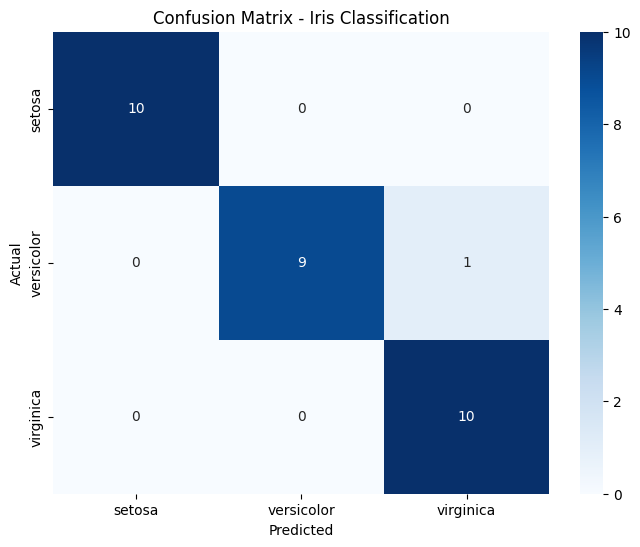

In [16]:
# Visualize confusion matrix nicely
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=species_names, 
            yticklabels=species_names)
plt.title('Confusion Matrix - Iris Classification')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [17]:
# Also print accuracy and precision
from sklearn.metrics import accuracy_score, precision_score

accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ Accuracy: {accuracy:.2%}")

# For multi-class precision, we use 'weighted' average
precision = precision_score(y_test, y_pred, average='weighted')
print(f"✅ Precision (weighted): {precision:.2%}")


✅ Accuracy: 96.67%
✅ Precision (weighted): 96.97%


In [18]:
import pickle

# Save the model as pickle file
with open('iris_model.pkl', 'wb') as file:
    pickle.dump(model, file)

print("✅ Model saved as 'iris_model.pkl'")

✅ Model saved as 'iris_model.pkl'


In [19]:
!pip install mlflow

In [20]:
import mlflow
import mlflow.sklearn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

C:\Users\taran\anaconda3\Lib\site-packages\pydantic\_internal\_fields.py:161: UserWarning: Field "model_name" has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(


In [21]:
# Set MLflow experiment
mlflow.set_experiment("Iris_Classification_Experiment")

# Train model (if not already trained)
model = LogisticRegression(max_iter=200, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

2026/04/23 20:27:33 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/04/23 20:27:33 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/04/23 20:27:33 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/04/23 20:27:33 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/04/23 20:27:33 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/04/23 20:27:33 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/04/23 20:27:34 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/23 20:27:34 INFO mlflow.store.db.utils: Updating database tables
2026/04/23 20:27:34 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/04/23 20:27:34 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/04/23 20:27:34 INFO alembic.runtime.migration: Running upgrade  -> 451aebb31d03, add metric step
2026/04/23 20:2

Accuracy: 0.9667
Precision: 0.9697
Recall: 0.9667
F1 Score: 0.9666


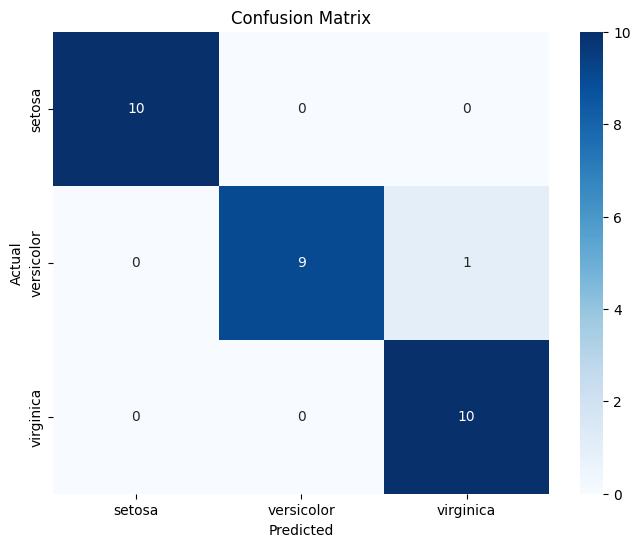

✅ MLflow tracking completed!
Run ID: 6fb4c2b0ca344c58a0f219464cf04af7


In [22]:
# Start MLflow run
with mlflow.start_run(run_name="Logistic_Regression_v1"):
    
    # Log parameters
    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_param("max_iter", 200)
    mlflow.log_param("random_state", 42)
    
    # Log metrics
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    
    # Save and log model
    joblib.dump(model, "iris_model.pkl")
    mlflow.log_artifact("iris_model.pkl")
    
    # Create and log confusion matrix plot
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['setosa', 'versicolor', 'virginica'],
                yticklabels=['setosa', 'versicolor', 'virginica'])
    plt.title('Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.savefig('confusion_matrix.png')
    mlflow.log_artifact('confusion_matrix.png')
    plt.show()
    
    print("✅ MLflow tracking completed!")
    print(f"Run ID: {mlflow.active_run().info.run_id}")

In [24]:
import os
print(os.getcwd())

C:\Users\taran\assessment
